<a href="https://colab.research.google.com/github/duykhanh-tran/TD-chat/blob/main/Linear_Regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện kiểm tra Đa cộng tuyến
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Thư viện chuẩn bị dữ liệu và mô hình
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

# Thư viện đánh giá
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

In [16]:
# 1. Đọc dữ liệu từ file Excel
# Đảm bảo file đã được upload lên Colab và đổi tên file trong code cho khớp nếu cần
df = pd.read_excel('Tạo Dữ Liệu Sinh Viên Cho Test.xlsx')

print("--- DỮ LIỆU GỐC TRƯỚC KHI XỬ LÝ ---")
print(df[['Diem_giua_ky', 'Diem_bai_tap', 'Diem_hoc_phan_cuoi_ky']].head(3))

# 2. Hàm dịch ngược lỗi ngày tháng của Excel về lại điểm số
def fix_excel_date(val):
    # Nếu ô bị bỏ trống
    if pd.isna(val):
        return val

    val_str = str(val).strip()

    if '2026' in val_str: # Nhận diện các ô bị lỗi biến thành năm 2026
        try:
            # Cắt bỏ phần " 00:00:00" do Pandas tự động sinh ra đối với dữ liệu Datetime
            date_part = val_str.split(' ')[0]
            parts = date_part.split('-')

            # Cấu trúc yyyy-mm-dd (VD: 2026-02-05)
            # Điểm thực tế người dùng gõ thường là ngày.tháng (5.2)
            day = float(parts[2])
            month = float(parts[1])
            return day + (month / 10)
        except:
            return np.nan # Trả về giá trị rỗng thay vì báo lỗi crash code

    # Nếu là điểm số bình thường (VD: 5.2)
    try:
        return float(val)
    except:
        return np.nan

# Áp dụng hàm sửa lỗi cho các cột điểm (Không cần .astype(float) nữa vì hàm đã tự trả về float)
cols_to_fix = ['Diem_giua_ky', 'Diem_bai_tap', 'Diem_hoc_phan_cuoi_ky']
for col in cols_to_fix:
    df[col] = df[col].apply(fix_excel_date)

# 3. Mã hóa biến phân loại (Categorical variables)
# Chuyển Online thành 1, Offline thành 0
if 'Hinh_thuc_hoc' in df.columns:
    df['Hinh_thuc_hoc'] = df['Hinh_thuc_hoc'].map({'Online': 1, 'Offline': 0})

# 4. Loại bỏ các cột không có giá trị dự đoán
# Ma_SV chỉ là định danh, không giúp ích cho thuật toán học
if 'Ma_SV' in df.columns:
    df = df.drop('Ma_SV', axis=1)

# Loại bỏ các dòng bị rỗng (nếu có)
df = df.dropna()

print("\n--- DỮ LIỆU SAU KHI LÀM SẠCH VÀ CHUẨN HÓA ---")
print(df.head())


--- DỮ LIỆU GỐC TRƯỚC KHI XỬ LÝ ---
          Diem_giua_ky         Diem_bai_tap Diem_hoc_phan_cuoi_ky
0  2026-02-05 00:00:00  2026-03-05 00:00:00   2026-07-04 00:00:00
1  2026-09-09 00:00:00  2026-03-07 00:00:00   2026-03-06 00:00:00
2  2026-02-04 00:00:00  2026-04-06 00:00:00   2026-06-04 00:00:00

--- DỮ LIỆU SAU KHI LÀM SẠCH VÀ CHUẨN HÓA ---
   So_buoi_vang  Diem_chuyen_can  Diem_giua_ky  Diem_bai_tap  So_tin_chi  \
0             3                4           5.2           5.3           3   
1             4                2           9.9           7.3           3   
2             2                6           4.2           6.4           4   
3             4                2           3.1           4.4           2   
4             4                2           8.3           5.5           2   

   Hinh_thuc_hoc  Diem_hoc_phan_cuoi_ky  
0              0                    4.7  
1              1                    6.3  
2              1                    4.6  
3              1            

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


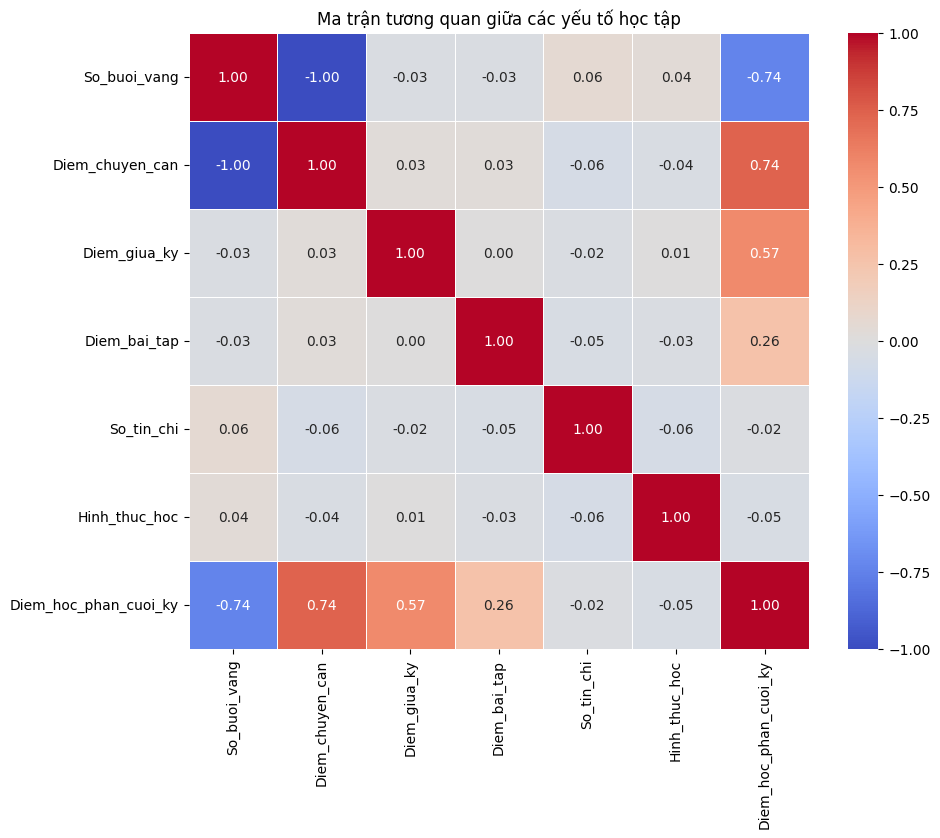


--- BẢNG CHỈ SỐ VIF ---
         Đặc trưng       VIF
0            const  0.000000
1     So_buoi_vang       inf
2  Diem_chuyen_can       inf
3     Diem_giua_ky  1.001422
4     Diem_bai_tap  1.003453
5       So_tin_chi  1.009581
6    Hinh_thuc_hoc  1.005778


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [18]:
# 3.1 Vẽ ma trận tương quan (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Ma trận tương quan giữa các yếu tố học tập")
plt.show()

# 3.2 Tính chỉ số VIF (Variance Inflation Factor)
# Tách các biến độc lập (X)
X_features = df.drop('Diem_hoc_phan_cuoi_ky', axis=1)
X_vif = add_constant(X_features) # Bắt buộc thêm hằng số để tính VIF chính xác

vif_data = pd.DataFrame()
vif_data["Đặc trưng"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("\n--- BẢNG CHỈ SỐ VIF ---")
print(vif_data)
# ĐÁNH GIÁ: Nếu đặc trưng nào có VIF > 5, đặc trưng đó bị Đa cộng tuyến.

In [19]:
# Tách X (Đặc trưng đầu vào) và y (Mục tiêu cần dự đoán)
X = df.drop('Diem_hoc_phan_cuoi_ky', axis=1)
y = df['Diem_hoc_phan_cuoi_ky']

# Chia tập Train / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa dữ liệu (Standardization)
# Cực kỳ quan trọng vì KNN và Ridge nhạy cảm với thang đo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
# Khởi tạo các mô hình (Linear là cốt lõi, các mô hình khác dùng để đối chiếu)
models = {
    "Linear Regression (Mô hình chính)": LinearRegression(),
    "Ridge Regression (Xử lý Đa cộng tuyến)": Ridge(alpha=1.0),
    "KNN Regression (Đối chiếu Phi tuyến)": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree (Đối chiếu Phi tuyến)": DecisionTreeRegressor(max_depth=5, random_state=42)
}

# Tạo list để lưu kết quả
results = []

print("--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH (TRÊN TẬP TEST 20%) ---")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Thuật toán": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2 Score": round(r2, 3)
    })

# In bảng kết quả
df_results = pd.DataFrame(results)
print(df_results.to_markdown(index=False))

--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH (TRÊN TẬP TEST 20%) ---
| Thuật toán                             |   MAE |   RMSE |   R2 Score |
|:---------------------------------------|------:|-------:|-----------:|
| Linear Regression (Mô hình chính)      | 0.341 |  0.415 |      0.89  |
| Ridge Regression (Xử lý Đa cộng tuyến) | 0.34  |  0.415 |      0.89  |
| KNN Regression (Đối chiếu Phi tuyến)   | 0.492 |  0.599 |      0.771 |
| Decision Tree (Đối chiếu Phi tuyến)    | 0.504 |  0.66  |      0.721 |


In [21]:
print("\n" + "="*60)
print("PHẦN ỨNG DỤNG: DỰ ĐOÁN ĐIỂM HỌC PHẦN CHO SINH VIÊN MỚI")
print("="*60)

# 1. Lấy mô hình Linear Regression (đã được huấn luyện ở Bước 5)
best_model = models["Linear Regression (Mô hình chính)"]

# 2. Giả lập nhập thông tin học tập của một sinh viên tên "Nam"
# Các cột phải đúng thứ tự: So_buoi_vang, Diem_chuyen_can, Diem_giua_ky, Diem_bai_tap, So_tin_chi, Hinh_thuc_hoc
# Ví dụ: Nam vắng 0 buổi, chuyên cần 10, giữa kỳ 8.5, bài tập 8.0, môn 3 tín chỉ, học Offline (0)
thong_tin_sinh_vien_Nam = pd.DataFrame({
    'So_buoi_vang': [1],
    'Diem_chuyen_can': [9.0],
    'Diem_giua_ky': [6.0],
    'Diem_bai_tap': [6.9],
    'So_tin_chi': [3],
    'Hinh_thuc_hoc': [1] # 0 là Offline, 1 là Online
})

# 3. Chuẩn hóa dữ liệu của Nam bằng đúng bộ tỷ lệ (scaler) đã dùng lúc huấn luyện
thong_tin_scaled = scaler.transform(thong_tin_sinh_vien_Nam)

# 4. Yêu cầu AI đưa ra dự đoán
diem_du_doan = best_model.predict(thong_tin_scaled)

# 5. In kết quả ra màn hình
print("DỮ LIỆU ĐẦU VÀO (Lịch sử học tập):")
print(thong_tin_sinh_vien_Nam.to_string(index=False))
print("-" * 40)
print(f"=> HỆ THỐNG AI DỰ ĐOÁN ĐIỂM HỌC PHẦN CUỐI KỲ: {round(diem_du_doan[0], 2)} điểm")
print("="*60)


PHẦN ỨNG DỤNG: DỰ ĐOÁN ĐIỂM HỌC PHẦN CHO SINH VIÊN MỚI
DỮ LIỆU ĐẦU VÀO (Lịch sử học tập):
 So_buoi_vang  Diem_chuyen_can  Diem_giua_ky  Diem_bai_tap  So_tin_chi  Hinh_thuc_hoc
            1              9.0           6.0           6.9           3              1
----------------------------------------
=> HỆ THỐNG AI DỰ ĐOÁN ĐIỂM HỌC PHẦN CUỐI KỲ: 6.38 điểm


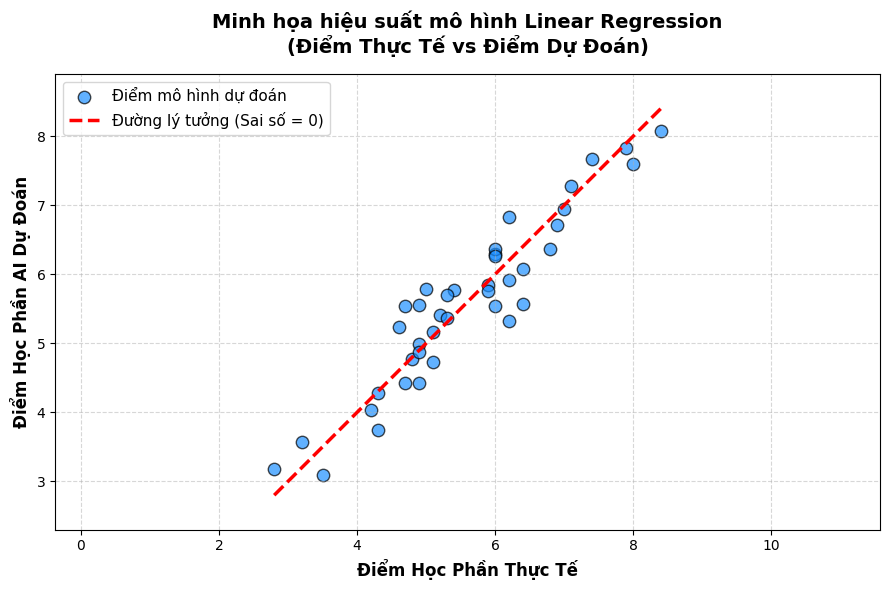

In [22]:
# Lấy dự đoán của Linear Regression trên tập Test
best_model = models["Linear Regression (Mô hình chính)"]
y_pred_linear = best_model.predict(X_test_scaled)

# Thiết lập kích thước khung hình
plt.figure(figsize=(9, 6))

# Vẽ các điểm dự đoán (scatter plot)
plt.scatter(y_test, y_pred_linear, color='dodgerblue', alpha=0.7, edgecolors='k', s=80, label='Điểm mô hình dự đoán')

# Vẽ đường chéo đỏ (Đường thẳng hoàn hảo: Dự đoán = Thực tế)
min_val = min(y_test.min(), y_pred_linear.min())
max_val = max(y_test.max(), y_pred_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2.5, label='Đường lý tưởng (Sai số = 0)')

# Trang trí biểu đồ cho chuyên nghiệp
plt.title('Minh họa hiệu suất mô hình Linear Regression\n(Điểm Thực Tế vs Điểm Dự Đoán)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Điểm Học Phần Thực Tế', fontsize=12, fontweight='bold')
plt.ylabel('Điểm Học Phần AI Dự Đoán', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Đảm bảo trục x và y có cùng thang đo để đường chéo góc 45 độ chuẩn xác
plt.axis('equal')
plt.xlim(min_val - 0.5, max_val + 0.5)
plt.ylim(min_val - 0.5, max_val + 0.5)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

### Giải thích Cell 1: Thư viện cần thiết

Cell này dùng để import tất cả các thư viện Python cần thiết cho quá trình phân tích dữ liệu và xây dựng mô hình. Các thư viện này bao gồm:

*   **`pandas`**: Để làm việc với dữ liệu dạng bảng (DataFrame).
*   **`numpy`**: Để thực hiện các phép toán số học.
*   **`matplotlib.pyplot`** và **`seaborn`**: Để trực quan hóa dữ liệu (vẽ biểu đồ).
*   **`statsmodels.stats.outliers_influence.variance_inflation_factor`** và **`statsmodels.tools.tools.add_constant`**: Để kiểm tra đa cộng tuyến (multicollinearity) giữa các biến độc lập bằng chỉ số VIF.
*   **`sklearn.model_selection.train_test_split`**: Để chia dữ liệu thành tập huấn luyện (training) và tập kiểm tra (testing).
*   **`sklearn.preprocessing.StandardScaler`**: Để chuẩn hóa dữ liệu (scaling).
*   **`sklearn.linear_model.LinearRegression`**, **`Ridge`**: Các thuật toán hồi quy tuyến tính (mô hình chính và mô hình xử lý đa cộng tuyến).
*   **`sklearn.neighbors.KNeighborsRegressor`**, **`sklearn.tree.DecisionTreeRegressor`**: Các thuật toán hồi quy phi tuyến tính để đối chiếu.
*   **`sklearn.metrics.mean_absolute_error`**, **`mean_squared_error`**, **`r2_score`**: Các chỉ số để đánh giá hiệu suất của mô hình.
*   **`math`**: Để thực hiện các phép toán toán học, ví dụ như tính căn bậc hai cho RMSE.

### Giải thích Cell 2: Tải và Tiền xử lý Dữ liệu

Cell này thực hiện các bước quan trọng để chuẩn bị dữ liệu trước khi đưa vào mô hình:

1.  **Đọc dữ liệu**: Tải dữ liệu từ file Excel có tên `'Tạo Dữ Liệu Sinh Viên Cho Test.xlsx'` vào DataFrame `df`.
2.  **`fix_excel_date(val)` function**: Hàm này được tạo ra để xử lý lỗi phổ biến khi Excel tự động chuyển đổi các số thập phân (ví dụ: 5.2 điểm) thành định dạng ngày tháng (ví dụ: 5-Feb-2026). Hàm này sẽ nhận diện và chuyển đổi các giá trị bị lỗi về lại dạng điểm số ban đầu. Nó cũng xử lý các trường hợp giá trị rỗng hoặc không chuyển đổi được bằng cách trả về `np.nan`.
3.  **Áp dụng hàm sửa lỗi**: Hàm `fix_excel_date` được áp dụng cho các cột điểm (`Diem_giua_ky`, `Diem_bai_tap`, `Diem_hoc_phan_cuoi_ky`).
4.  **Mã hóa biến phân loại**: Cột `Hinh_thuc_hoc` (hình thức học) được chuyển đổi từ `'Online'` thành `1` và `'Offline'` thành `0`. Đây là bước cần thiết vì các mô hình học máy thường làm việc với dữ liệu số.
5.  **Loại bỏ cột không cần thiết**: Cột `Ma_SV` (Mã sinh viên) được loại bỏ vì nó chỉ là định danh và không có giá trị dự đoán cho mô hình.
6.  **Xử lý giá trị rỗng**: Các hàng có bất kỳ giá trị `NaN` (rỗng) nào sau các bước xử lý trên sẽ bị loại bỏ khỏi DataFrame `df`.

### Giải thích Cell 3: Phân tích Đa cộng tuyến và Tương quan

Cell này tập trung vào việc phân tích mối quan hệ giữa các biến, đặc biệt là kiểm tra đa cộng tuyến:

1.  **Vẽ ma trận tương quan (Heatmap)**: Biểu đồ heatmap được sử dụng để hiển thị ma trận tương quan giữa tất cả các cột số trong DataFrame `df`. Giá trị tương quan nằm trong khoảng từ -1 đến 1. Giá trị gần 1 hoặc -1 cho thấy mối quan hệ tuyến tính mạnh (tương quan thuận/nghịch), giá trị gần 0 cho thấy mối quan hệ yếu. Việc này giúp chúng ta hiểu mối liên hệ giữa các yếu tố và biến mục tiêu.
2.  **Tính chỉ số VIF (Variance Inflation Factor)**: VIF được dùng để phát hiện và đo lường mức độ đa cộng tuyến giữa các biến độc lập.
    *   `X_features` được tạo bằng cách loại bỏ biến mục tiêu (`Diem_hoc_phan_cuoi_ky`).
    *   `add_constant` thêm một cột hằng số vào `X_vif`, điều này cần thiết cho việc tính toán VIF chính xác.
    *   VIF được tính cho từng biến và lưu vào `vif_data`.
    *   **Đánh giá**: Nếu một đặc trưng có VIF > 5 (hoặc đôi khi > 10, tùy theo quy ước), nó được coi là có vấn đề về đa cộng tuyến, nghĩa là nó tương quan quá mạnh với một hoặc nhiều biến độc lập khác. Điều này có thể ảnh hưởng đến độ ổn định và khả năng giải thích của mô hình hồi quy.

### Giải thích Cell 4: Chia dữ liệu và Chuẩn hóa

Cell này chuẩn bị dữ liệu cho quá trình huấn luyện mô hình:

1.  **Tách X và y**: Dữ liệu được chia thành:
    *   `X`: Các biến độc lập (đặc trưng đầu vào), là tất cả các cột trừ `Diem_hoc_phan_cuoi_ky`.
    *   `y`: Biến phụ thuộc (mục tiêu cần dự đoán), là cột `Diem_hoc_phan_cuoi_ky`.
2.  **Chia tập Train / Test**: Dữ liệu được chia thành hai phần:
    *   `X_train`, `y_train`: 80% dữ liệu dùng để huấn luyện mô hình.
    *   `X_test`, `y_test`: 20% dữ liệu dùng để kiểm tra hiệu suất của mô hình sau khi huấn luyện.
    *   `test_size=0.2` chỉ định 20% cho tập kiểm tra, `random_state=42` đảm bảo rằng việc chia dữ liệu là nhất quán mỗi lần chạy.
3.  **Chuẩn hóa dữ liệu (Standardization)**: Dữ liệu được chuẩn hóa bằng `StandardScaler`.
    *   `fit_transform(X_train)`: Học các tham số chuẩn hóa (mean và standard deviation) từ tập huấn luyện và áp dụng chúng để chuyển đổi `X_train`.
    *   `transform(X_test)`: Áp dụng cùng các tham số đã học từ `X_train` để chuyển đổi `X_test`. Điều quan trọng là không `fit` lại `scaler` trên tập kiểm tra để tránh rò rỉ dữ liệu (data leakage). Chuẩn hóa giúp các mô hình như Linear Regression, Ridge, và KNN hoạt động tốt hơn vì chúng nhạy cảm với thang đo của dữ liệu.

### Giải thích Cell 5: Huấn luyện và Đánh giá Mô hình

Cell này là nơi các mô hình học máy được xây dựng, huấn luyện và đánh giá:

1.  **Khởi tạo các mô hình**: Một từ điển `models` được tạo ra chứa các mô hình hồi quy khác nhau:
    *   `LinearRegression`: Mô hình hồi quy tuyến tính cơ bản.
    *   `Ridge`: Mô hình hồi quy Ridge, một dạng của hồi quy tuyến tính có thêm phần tử chuẩn hóa L2 để xử lý đa cộng tuyến và overfitting.
    *   `KNeighborsRegressor`: Mô hình K-Nearest Neighbors (KNN) cho hồi quy, một thuật toán phi tuyến tính.
    *   `DecisionTreeRegressor`: Mô hình Cây quyết định cho hồi quy, cũng là một thuật toán phi tuyến tính.
2.  **Huấn luyện và Đánh giá**: Một vòng lặp `for` chạy qua từng mô hình trong từ điển `models`:
    *   `model.fit(X_train_scaled, y_train)`: Huấn luyện mô hình trên dữ liệu huấn luyện đã được chuẩn hóa.
    *   `y_pred = model.predict(X_test_scaled)`: Sử dụng mô hình đã huấn luyện để dự đoán điểm trên dữ liệu kiểm tra đã chuẩn hóa.
    *   **Tính toán các chỉ số đánh giá**: Các chỉ số sau được tính toán để đánh giá hiệu suất của mỗi mô hình:
        *   `MAE` (Mean Absolute Error): Sai số tuyệt đối trung bình, đo lường độ lớn trung bình của các lỗi.
        *   `MSE` (Mean Squared Error): Sai số bình phương trung bình, gán trọng số lớn hơn cho các lỗi lớn.
        *   `RMSE` (Root Mean Squared Error): Căn bậc hai của MSE, có cùng đơn vị với biến mục tiêu.
        *   `R2 Score` (Hệ số xác định): Đo lường tỷ lệ phương sai của biến phụ thuộc được giải thích bởi các biến độc lập trong mô hình. Giá trị gần 1 cho thấy mô hình phù hợp tốt với dữ liệu.
3.  **Lưu và In kết quả**: Các chỉ số đánh giá được làm tròn và lưu vào danh sách `results`. Cuối cùng, `df_results` DataFrame được tạo và in ra màn hình dưới dạng bảng Markdown để dễ dàng so sánh hiệu suất giữa các mô hình.

### Giải thích Cell 6: Ứng dụng Dự đoán cho Sinh viên mới

Cell này minh họa cách sử dụng mô hình tốt nhất để đưa ra dự đoán cho một trường hợp sinh viên mới:

1.  **Chọn mô hình tốt nhất**: Mô hình `Linear Regression` được chọn làm `best_model` (dựa trên kết quả đánh giá, nó có R2 Score cao nhất).
2.  **Giả lập thông tin sinh viên mới**: Một DataFrame `thong_tin_sinh_vien_Nam` được tạo để chứa thông tin giả định của một sinh viên tên Nam. Các cột và thứ tự của chúng phải khớp với dữ liệu huấn luyện.
3.  **Chuẩn hóa thông tin sinh viên**: Dữ liệu của sinh viên Nam được chuẩn hóa bằng chính `scaler` đã được dùng để chuẩn hóa tập huấn luyện. Điều này đảm bảo rằng dữ liệu mới nằm trên cùng thang đo với dữ liệu mà mô hình đã được huấn luyện.
4.  **Dự đoán điểm**: `best_model.predict(thong_tin_scaled)` được gọi để dự đoán điểm học phần cuối kỳ cho sinh viên Nam.
5.  **In kết quả**: Thông tin đầu vào và điểm dự đoán cuối cùng (làm tròn đến 2 chữ số thập phân) được in ra màn hình.

### Giải thích Cell 7: Trực quan hóa hiệu suất mô hình (Tập Test)

Cell này tạo ra một biểu đồ trực quan để đánh giá hiệu suất của mô hình Hồi quy Tuyến tính trên tập dữ liệu kiểm tra:

1.  **Lấy dự đoán từ Linear Regression**: Lấy `y_pred_linear` (các giá trị dự đoán) từ mô hình Linear Regression trên tập `X_test_scaled`.
2.  **Thiết lập biểu đồ**: Tạo một `figure` với kích thước cụ thể để vẽ biểu đồ.
3.  **Vẽ biểu đồ phân tán (Scatter Plot)**:
    *   `plt.scatter(y_test, y_pred_linear, ...)`: Vẽ các điểm, với trục hoành là `Điểm Học Phần Thực Tế` (`y_test`) và trục tung là `Điểm Học Phần AI Dự Đoán` (`y_pred_linear`).
    *   Các điểm nằm càng gần đường chéo đỏ (đường lý tưởng) thì mô hình dự đoán càng chính xác.
4.  **Vẽ đường lý tưởng (Perfect line)**:
    *   Một đường chéo đỏ được vẽ từ điểm nhỏ nhất đến điểm lớn nhất của cả `y_test` và `y_pred_linear`.
    *   Đường này biểu thị trường hợp lý tưởng mà ở đó `Điểm Thực Tế = Điểm Dự Đoán` (sai số bằng 0). Nó giúp trực quan hóa mức độ sai lệch của các điểm dự đoán so với thực tế.
5.  **Trang trí biểu đồ**: Các tiêu đề, nhãn trục, chú thích (legend) và lưới (grid) được thêm vào để biểu đồ trở nên rõ ràng và chuyên nghiệp hơn.
6.  **Đảm bảo trục có cùng thang đo**: `plt.axis('equal')` và các thiết lập `xlim`, `ylim` đảm bảo rằng trục x và y có cùng tỷ lệ, giúp đường chéo 45 độ hiển thị chính xác và việc đánh giá trực quan hiệu suất trở nên dễ dàng hơn.
7.  **Hiển thị biểu đồ**: `plt.show()` hiển thị biểu đồ đã hoàn chỉnh.